In [1]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import xskillscore as xs

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

In [17]:
ds_static = xr.open_dataset('/glade/derecho/scratch/turuncu/data/static.nc')
lsm = ds_static.lsm.isel(valid_time=0)
over_ocean = (lsm == 0)
over_land = (lsm > 0)

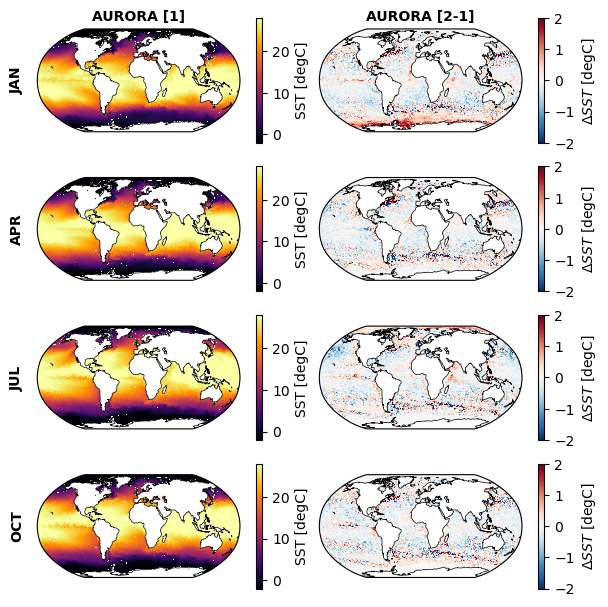

In [20]:
fig, ax = plt.subplots(4, 2, figsize=(6, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/pred_merged_35d_remap_bil.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/pred_merged_35d_remap_bil.nc"))

    # Aurora forced (1-way)
    data_aur1 = ds_aur1_mean.sst.where(over_ocean).isel(time=139)-273.15
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # Aurora forced (2-way)
    data_aur2 = ds_aur2_mean.sst.where(over_ocean).isel(time=139)-273.15
    data_aur2_diff = data_aur2-data_aur1
    im1 = data_aur2_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("AURORA [1]", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AURORA [2-1]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

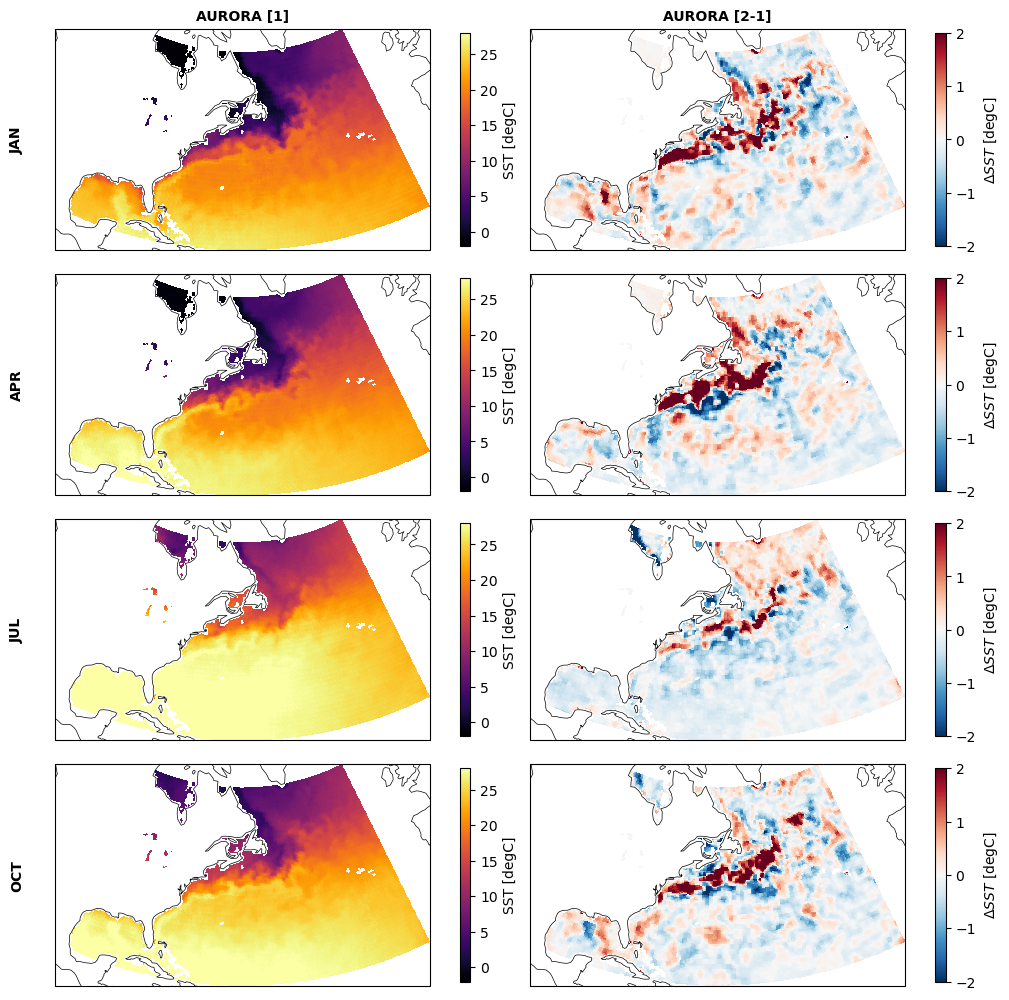

In [34]:
# North Atlantic Ocean
min_lat, max_lat = 20, 60
min_lon, max_lon = 260, 340

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0,
    central_latitude=(min_lat+max_lat)/2.0,
    standard_parallels=(20.0, 60.0)
)

# Create plot
fig, ax = plt.subplots(4, 2, figsize=(10, 10), layout='constrained', subplot_kw={'projection': projection})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/pred_merged_35d_remap_bil.nc"))
    ds_aur1_mean = ds_aur1_mean.reindex(latitude=ds_aur1_mean.latitude[::-1])
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/pred_merged_35d_remap_bil.nc"))
    ds_aur2_mean = ds_aur2_mean.reindex(latitude=ds_aur2_mean.latitude[::-1])

    # Subset dataset
    ds_aur1_mean = ds_aur1_mean.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
    ds_aur2_mean = ds_aur2_mean.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))

    # Aurora forced (1-way)
    data_aur1 = ds_aur1_mean.sst.where(over_ocean).isel(time=139)-273.15
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # Aurora forced (2-way)
    data_aur2 = ds_aur2_mean.sst.where(over_ocean).isel(time=139)-273.15
    data_aur2_diff = data_aur2-data_aur1
    im1 = data_aur2_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("AURORA [1]", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AURORA [2-1]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

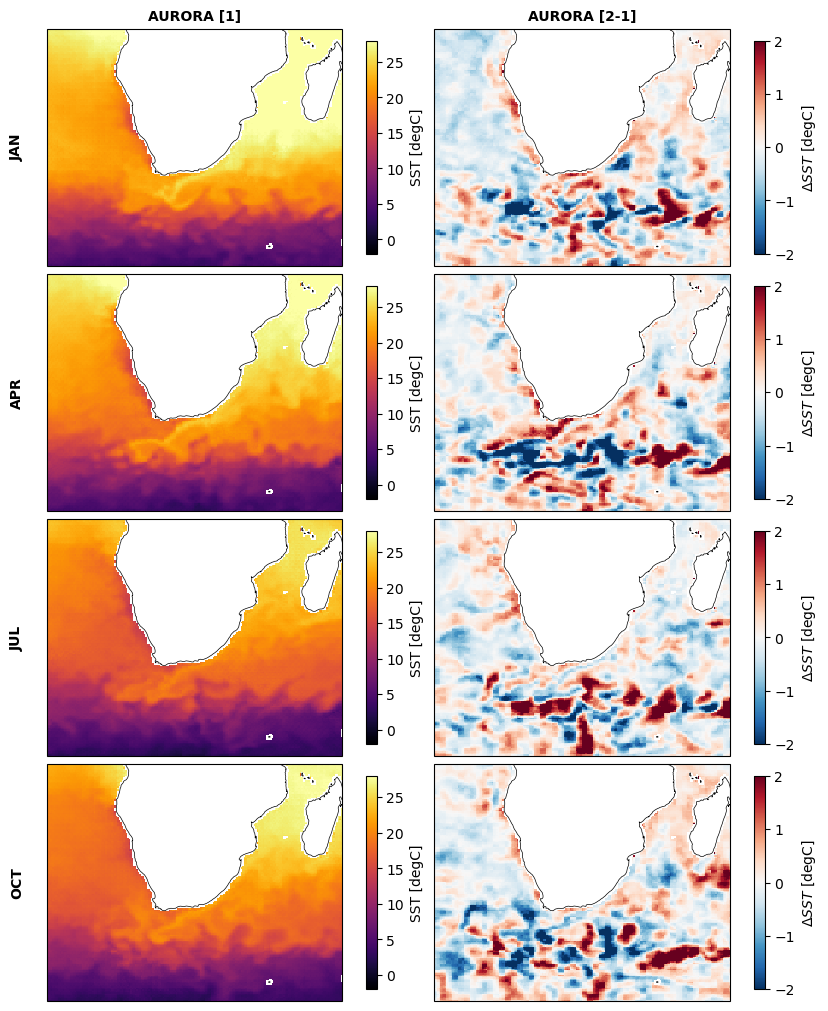

In [84]:
def to_180(ds):
    """Wrap longitude coordinates as range [-180,180]."""
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby('longitude')
    return ds

# North Atlantic Ocean
min_lat, max_lat = -50, -10
min_lon, max_lon = -30, 50

# Create plot
fig, ax = plt.subplots(4, 2, figsize=(8, 10), layout='constrained', subplot_kw={'projection': ccrs.PlateCarree()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/pred_merged_35d_remap_bil.nc"))
    ds_aur1_mean = ds_aur1_mean.reindex(latitude=ds_aur1_mean.latitude[::-1])
    ds_aur1_mean = to_180(ds_aur1_mean)
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/pred_merged_35d_remap_bil.nc"))
    ds_aur2_mean = ds_aur2_mean.reindex(latitude=ds_aur2_mean.latitude[::-1])
    ds_aur2_mean = to_180(ds_aur2_mean)

    # Subset dataset
    ds_aur1_mean = ds_aur1_mean.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
    ds_aur2_mean = ds_aur2_mean.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))

    # Aurora forced (1-way)
    data_aur1 = ds_aur1_mean.sst.where(over_ocean).isel(time=139)-273.15
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=28, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # Aurora forced (2-way)
    data_aur2 = ds_aur2_mean.sst.where(over_ocean).isel(time=139)-273.15
    data_aur2_diff = data_aur2-data_aur1
    im1 = data_aur2_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("AURORA [1]", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AURORA [2-1]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

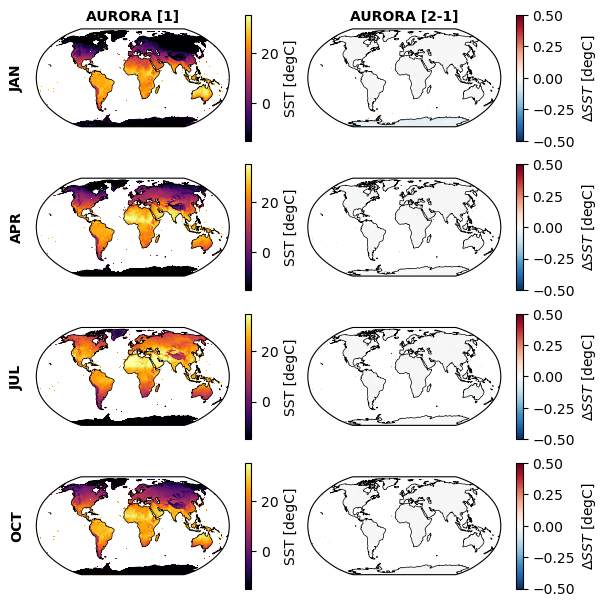

In [87]:
fig, ax = plt.subplots(4, 2, figsize=(6, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/pred_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/pred_merged_35d_remap_bil_tmean.nc"))

    # Aurora forced (1-way)
    data_aur1 = ds_aur1_mean['2t'].where(over_land).isel(time=0)-273.15
    im0 = data_aur1.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-15, vmax=35, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SST [degC]')

    # Aurora forced (2-way)
    data_aur2 = ds_aur2_mean['2t'].where(over_land).isel(time=0)-273.15
    data_aur2_diff = data_aur2-data_aur1
    im1 = data_aur2_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-0.5, vmax=0.5, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    fig.colorbar(im1, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SST$ [degC]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("AURORA [1]", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("AURORA [2-1]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1